# Transmission Line Fault Detection Using Machine Learning




## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import warnings
warnings.filterwarnings('ignore')


## 2. Load the Dataset

In [3]:
df = pd.read_csv(
    "/kaggle/input/datasets/esathyaprakash/electrical-fault-detection-and-classification/classData.csv"
)

print("Dataset shape:", df.shape)
display(df.head())


Dataset shape: (7861, 10)


,G,C,B,A,Ia,Ib,Ic,Va,Vb,Vc
0,1,0,0,1,-151.291812,-9.677452,85.800162,0.400750,-0.132935,-0.267815
1,1,0,0,1,-336.186183,-76.283262,18.328897,0.312732,-0.123633,-0.189099
2,1,0,0,1,-502.891583,-174.648023,-80.924663,0.265728,-0.114301,-0.151428
3,1,0,0,1,-593.941905,-217.703359,-124.891924,0.235511,-0.104940,-0.130570
4,1,0,0,1,-643.663617,-224.159427,-132.282815,0.209537,-0.095554,-0.113983


## 3. Inspect the Dataset

In [4]:
print("Columns:")
print(df.columns.tolist())

print("\nData types and non-null values:")
df.info()


Columns:
['G', 'C', 'B', 'A', 'Ia', 'Ib', 'Ic', 'Va', 'Vb', 'Vc']

Data types and non-null values:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7861 entries, 0 to 7860
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   G       7861 non-null   int64  
 1   C       7861 non-null   int64  
 2   B       7861 non-null   int64  
 3   A       7861 non-null   int64  
 4   Ia      7861 non-null   float64
 5   Ib      7861 non-null   float64
 6   Ic      7861 non-null   float64
 7   Va      7861 non-null   float64
 8   Vb      7861 non-null   float64
 9   Vc      7861 non-null   float64
dtypes: float64(6), int64(4)
memory usage: 614.3 KB


In [5]:
print("Summary statistics:")
display(df.describe())


Summary statistics:


,G,C,B,A,Ia,Ib,Ic,Va,Vb,Vc
count,7861.000000,7861.000000,7861.000000,7861.000000,7861.000000,7861.000000,7861.000000,7861.000000,7861.000000,7861.000000
mean,0.432006,0.411271,0.555527,0.571429,13.721194,-44.845268,34.392394,-0.007667,0.001152,0.006515
std,0.495387,0.492095,0.496939,0.494903,464.741671,439.269195,371.107412,0.289150,0.313437,0.307897
min,0.000000,0.000000,0.000000,0.000000,-883.542316,-900.526951,-883.357762,-0.620748,-0.608016,-0.612709
25%,0.000000,0.000000,0.000000,0.000000,-119.802518,-271.845947,-61.034219,-0.130287,-0.159507,-0.215977
50%,0.000000,0.000000,1.000000,1.000000,2.042805,5.513317,-4.326711,-0.005290,0.001620,0.009281
75%,1.000000,1.000000,1.000000,1.000000,227.246377,91.194282,49.115141,0.111627,0.153507,0.239973
max,1.000000,1.000000,1.000000,1.000000,885.738571,889.868884,901.274261,0.595342,0.627875,0.600179


## 4. Create the Fault Target

The columns `G`, `C`, `B`, and `A` indicate whether the ground/phase fault conditions are active.

We combine them into one binary target:

- `0` → No Fault
- `1` → Fault

These four indicator columns are **not** used as ML inputs because they directly contain fault information.


In [6]:
df['Fault'] = (
    (df['G'] == 1) |
    (df['C'] == 1) |
    (df['B'] == 1) |
    (df['A'] == 1)
).astype(int)

print(df['Fault'].value_counts())


Fault
1    5496
0    2365
Name: count, dtype: int64


## 5. Fault Distribution

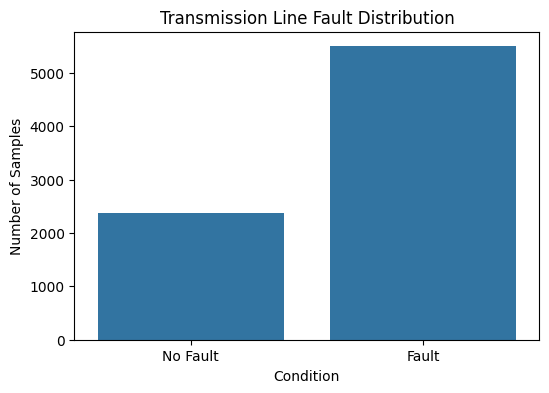

In [7]:
plt.figure(figsize=(6, 4))

sns.countplot(
    data=df,
    x='Fault'
)

plt.xticks([0, 1], ['No Fault', 'Fault'])
plt.xlabel('Condition')
plt.ylabel('Number of Samples')
plt.title('Transmission Line Fault Distribution')

plt.show()


## 6. Select Features and Target

The model uses only the measured three-phase voltages and currents.


In [8]:
features = ['Ia', 'Ib', 'Ic', 'Va', 'Vb', 'Vc']

X = df[features]
y = df['Fault']

print("Features:", features)
print("X shape:", X.shape)
print("y shape:", y.shape)


Features: ['Ia', 'Ib', 'Ic', 'Va', 'Vb', 'Vc']
X shape: (7861, 6)
y shape: (7861,)


## 7. Train-Test Split

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples :", X_test.shape[0])


Training samples: 6288
Testing samples : 1573


## 8. Train Random Forest

In [10]:
model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

print("Random Forest model trained successfully.")


Random Forest model trained successfully.


## 9. Evaluate the Model

In [11]:
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test Accuracy: {accuracy * 100:.2f}%")


Test Accuracy: 1.0000
Test Accuracy: 100.00%


In [12]:
print(classification_report(
    y_test,
    y_pred,
    target_names=['No Fault', 'Fault']
))


              precision    recall  f1-score   support

    No Fault       1.00      1.00      1.00       473
       Fault       1.00      1.00      1.00      1100

    accuracy                           1.00      1573
   macro avg       1.00      1.00      1.00      1573
weighted avg       1.00      1.00      1.00      1573



## 10. Confusion Matrix

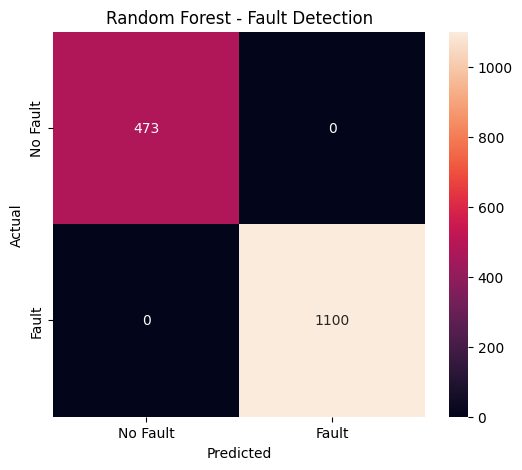

In [13]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=['No Fault', 'Fault'],
    yticklabels=['No Fault', 'Fault']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Random Forest - Fault Detection')

plt.show()


## 11. Feature Importance

In [14]:
importance = pd.DataFrame({
    'Feature': features,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False)

display(importance)


,Feature,Importance
0,Ia,0.320580
1,Ib,0.277444
2,Ic,0.155889
3,Va,0.093858
5,Vc,0.084571
4,Vb,0.067659


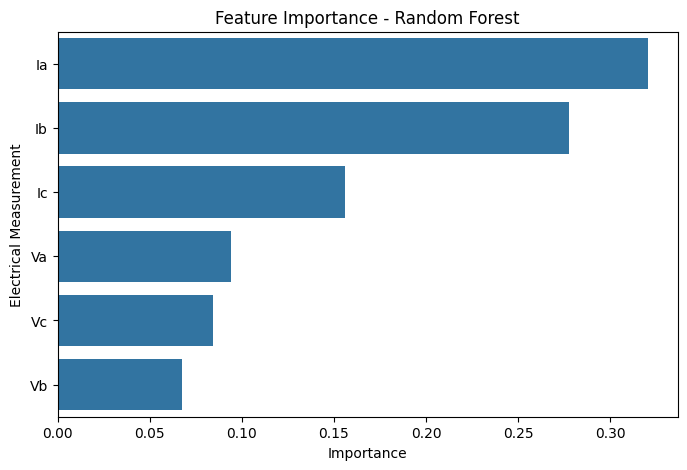

In [15]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=importance,
    x='Importance',
    y='Feature'
)

plt.xlabel('Importance')
plt.ylabel('Electrical Measurement')
plt.title('Feature Importance - Random Forest')

plt.show()


## 12. Compare with Logistic Regression

Logistic Regression is included as a simple baseline. Random Forest can capture nonlinear relationships in the electrical measurements.


In [16]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

print(
    f"Logistic Regression Accuracy: "
    f"{accuracy_score(y_test, lr_pred) * 100:.2f}%"
)
print(
    f"Random Forest Accuracy: "
    f"{accuracy_score(y_test, y_pred) * 100:.2f}%"
)


Logistic Regression Accuracy: 69.93%
Random Forest Accuracy: 100.00%


## 13. Test the Model on an Unseen Test Sample

In [17]:
sample = X_test.iloc[[0]]
actual = y_test.iloc[0]

predicted = model.predict(sample)[0]
probability = model.predict_proba(sample)[0]

print("Actual   :", "FAULT" if actual == 1 else "NO FAULT")
print("Predicted:", "FAULT" if predicted == 1 else "NO FAULT")

print("\nModel probability:")
print(f"No Fault: {probability[0] * 100:.2f}%")
print(f"Fault   : {probability[1] * 100:.2f}%")


Actual   : FAULT
Predicted: FAULT

Model probability:
No Fault: 0.00%
Fault   : 100.00%


## 14. Save the Trained Model

In [18]:
import joblib

joblib.dump(model, 'transmission_line_fault_model.pkl')

print("Model saved as: transmission_line_fault_model.pkl")


Model saved as: transmission_line_fault_model.pkl
